# Case 4 - Tritium Spatial Estimation
Welcome to the demonstration notebook where we'll spatially estimate tritium using the **pylenm** package!<br>
Let’s get started!

## Notebook roadmap

This demo is organized into short sections so you can follow it top-to-bottom.

- Load and pre-process data
- Build the spatial model

> Tip: You can run the notebook cell-by-cell, or use **Run All** once the dependencies are installed.


## Setup
Make sure to install pylenm from https://pypi.org/project/pylenm/ by running `pip install pylenm` in your environment terminal. Once completed, you should be able to import the package. Note: to update to the latest version of pylenm run: `pip install pylenm --upgrade`

In [ ]:
# pip install pylenm

In [2]:
# pip install pyproj

In [3]:
# pip install rasterio

In [4]:
# pip install elevation

In [5]:
# pip install richdem

In [1]:
# Basics
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.preprocessing import  MinMaxScaler
from sklearn.model_selection import LeaveOneOut
from math import sqrt
from sklearn.metrics import r2_score

# pylenm
import pylenm
print("pylenm version: ", pylenm.__version__)
from pylenm import PylenmDataFactory

# GIS data layers
from pyproj import Transformer, CRS
import rasterio
import elevation
import richdem as rd

plt.rcParams["font.family"] = "Times New Roman"

pylenm version:  1.2.3


## Load and pre-process data

### Load GIS data layers

In [2]:
# Load GIS elevation data
dem_path = "data/FArea-30m-DEM_cropped.tif"

# Uncommented the lines below to load date from GitHub
# raw_base = "https://raw.githubusercontent.com/hkzhao7/pylenm/main/notebooks/data/"
# dem_path = raw_base + "FArea-30m-DEM_cropped.tif"

farea_dem = rd.LoadGDAL(dem_path)
farea_ras = rasterio.open(dem_path)

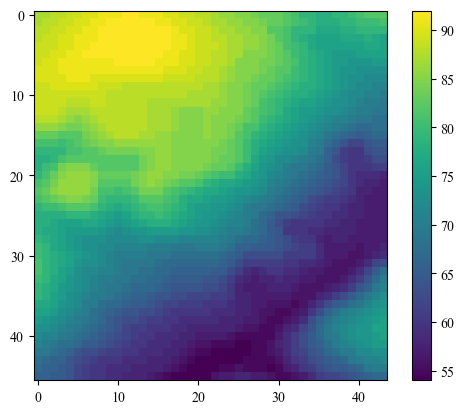

In [3]:
plt.imshow(farea_dem, interpolation='none')
plt.colorbar()
plt.show()

In [4]:
crs = CRS.from_epsg("26917")
proj = Transformer.from_crs(crs.geodetic_crs, crs)

x_loc = np.zeros([farea_ras.height, farea_ras.width])
y_loc = np.zeros([farea_ras.height, farea_ras.width])
for i in range(farea_ras.height):
  for j in range(farea_ras.width):
    lon = farea_ras.xy(i,j)[0]
    lat = farea_ras.xy(i,j)[1]
    utm_x, utm_y =proj.transform(lat,lon) # Latitude/Longitude to UTM
    x_loc[i,j] = utm_x
    y_loc[i,j] = utm_y

In [5]:
slope = rd.TerrainAttribute(farea_dem, attrib='slope_riserun')
accum = rd.FlowAccumulation(farea_dem, method='D8')
twi   = np.log(accum/slope)

### Load station time series data + preprocess

In [6]:
# --- Option A (default): load demo data locally ---
# If you cloned the repo, the demo data is under: notebooks/data/
url_1 = 'data/farea_data_thru_2015q3_reduced_demo.csv'
url_2 = 'data/farea_station_construction_data.csv'

# # --- Option B: load demo data directly from GitHub (no local repo needed) ---
# # Useful for running notebooks on Google Colab or when you don't have the repo cloned.
# raw_base = "https://raw.githubusercontent.com/hkzhao7/pylenm/main/notebooks/data/"
# url_1 = raw_base + "farea_data_thru_2015q3_reduced_demo.csv"
# url_2 = raw_base + "farea_station_construction_data.csv"

concentration_data = pd.read_csv(url_1)
construction_data = pd.read_csv(url_2)

pylenm_df = PylenmDataFactory(concentration_data)
pylenm_df.simplify_data(inplace=True)
pylenm_df.setConstructionData(construction_data)

Successfully imported the data!

Successfully imported the construction data!



Data summary for Tritium

In [7]:
analyte = 'TRITIUM'

tr_details = pylenm_df.get_analyte_details(analyte)
tr_details

,Start Date,End Date,Date Range (days),Unique samples
Station Name,,,,
FSB-077,1990-01-01,2006-10-16,6132,65
FSB-111C,1990-01-01,2006-10-17,6133,67
FSB-105C,1990-01-01,2006-10-19,6135,67
FSB-111D,1990-01-01,2006-10-26,6142,68
FSB-107D,1990-01-01,2007-02-01,6240,68
...,...,...,...,...
FSB-146D,2015-04-29,2015-09-09,133,9
FSB-145D,2015-04-30,2015-09-09,132,9
FSB-143D,2015-05-04,2015-09-09,128,9


Select stations that have enough and recent samples

In [14]:
n_samples = tr_details['Unique samples']
end_date = tr_details['End Date']
start_date = tr_details['Start Date']
station_names  = tr_details.index
station_enough = station_names[n_samples>20]

station_recent = station_names[end_date> datetime.strptime('2015-01-01', '%Y-%m-%d').date()]
station_old    = station_names[start_date< datetime.strptime('2006-01-01', '%Y-%m-%d').date()]

Temporal interpolation of the time series at equal frequency

In [15]:
tr_interp = pylenm_df.interpolate_stations_by_analyte(analyte, frequency='1M', rm_outliers=True, z_threshold=3)

In [16]:
tr_interp[tr_interp <= 0] = 0.001

Select the upper aquifer stations and the stations that have enough samples

44 stations


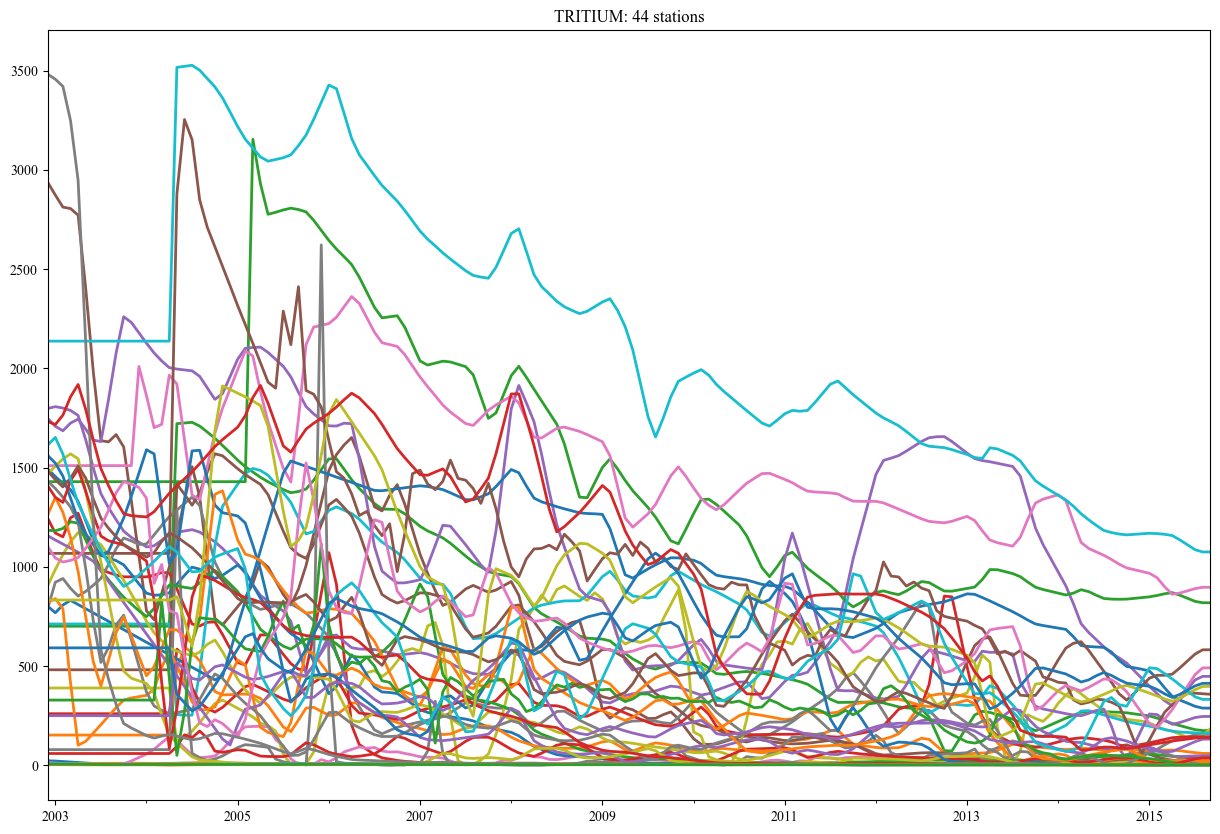

In [17]:
active = list(np.unique(pylenm_df.filter_by_column(pylenm_df.get_Construction_Data(), col='STATION_USE', equals=['ACTIVE']).index))
upper_stations = list(np.unique(pylenm_df.filter_by_column(pylenm_df.get_Construction_Data(), col='AQUIFER', equals=['UAZ_UTRAU']).index))
station_only_D = list(set(upper_stations) & set(tr_interp.columns)& set(station_enough)& set(station_recent)& set(station_old) & set(active))
tr_interp = tr_interp[station_only_D]
tr_interp.plot(figsize=(15,10), legend=False, linewidth=2, title=str(analyte + ": {} stations".format(tr_interp.shape[1])))
print(tr_interp.shape[1], "stations")

In [18]:
keep = list(tr_interp.describe().T[tr_interp.describe().T['min']>0].T.columns)
tr_interp = tr_interp[keep]

Let's remove the 'bad' time series stations

In [19]:
bad_ones = ['FSB-089D', 'FSB-128D', 'FSB-104D', 'FSB-091D', 'FSB-099D', 'FSB-117D']
tr_interp = tr_interp.drop(columns=bad_ones)

In [20]:
# Reorder columns to be in alphabetical order
tr_interp = tr_interp.reindex(sorted(tr_interp.columns), axis=1)

38 stations


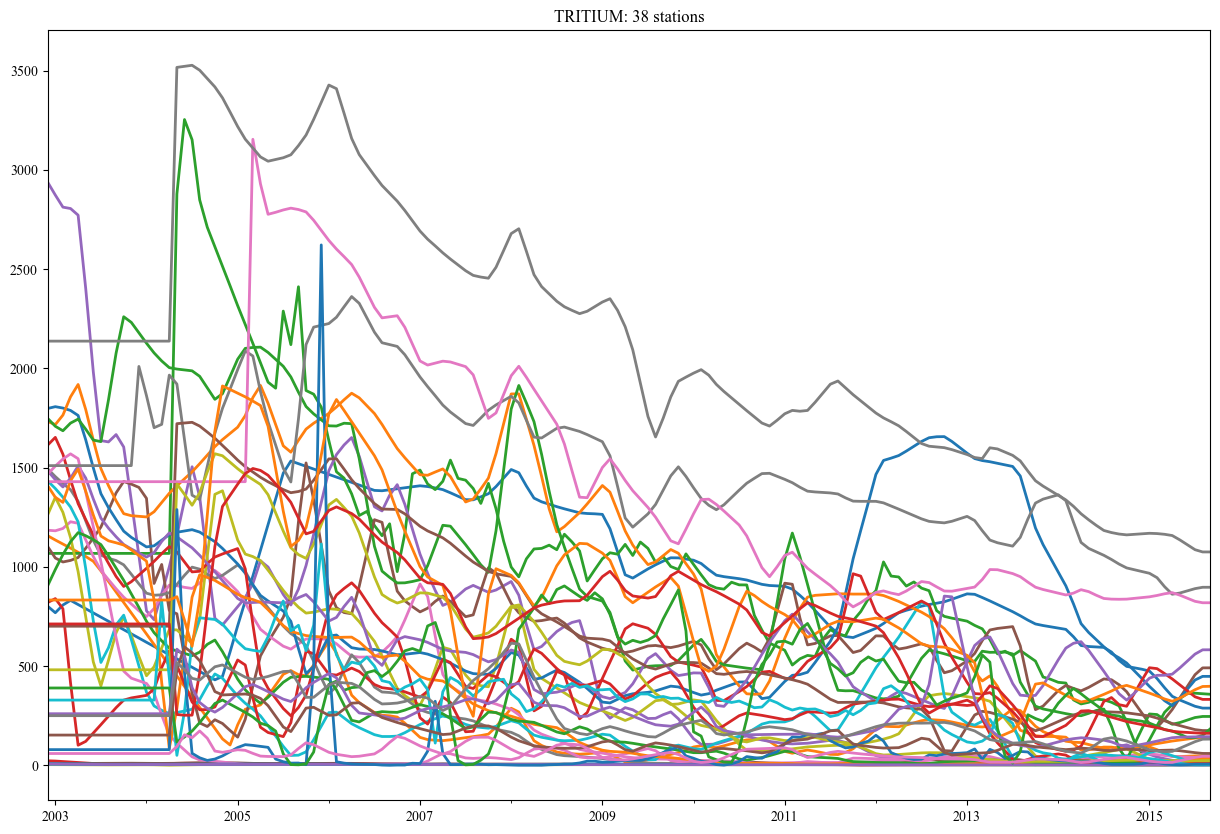

In [21]:
tr_interp.plot(figsize=(15,10), legend=False, linewidth=2, title=str(analyte + ": {} stations".format(tr_interp.shape[1])))
print(tr_interp.shape[1], "stations")

### Prepare station location (coordinates) data

In [22]:
station_info = pylenm_df.get_Construction_Data()

Match the station indecies between the time series and locations

In [23]:
shared_stations = list(set(station_info.index) & set(tr_interp.columns))
tr_interp = tr_interp[shared_stations]
# Reorder columns to be in alphabetical order
tr_interp = tr_interp.reindex(sorted(tr_interp.columns), axis=1)

station_info = station_info.T[shared_stations]
# Reorder columns to be in alphabetical order
station_info = station_info.reindex(sorted(station_info.columns), axis=1)
station_info = station_info.T

In [24]:
crs = CRS.from_epsg("26917")
proj = Transformer.from_crs(crs.geodetic_crs, crs)
UTM_x, UTM_y = proj.transform(station_info.LATITUDE,station_info.LONGITUDE)

Convert the ground-surface elevation from feet to meters

In [25]:
elev = station_info.REFERENCE_ELEVATION
elev.index = station_info.index
elev = elev.T
elev = elev * 0.3048 # convert to meters

In [26]:
# tr_interp = np.log2(tr_interp)
tr_interp = np.log10(tr_interp)

<Axes: >

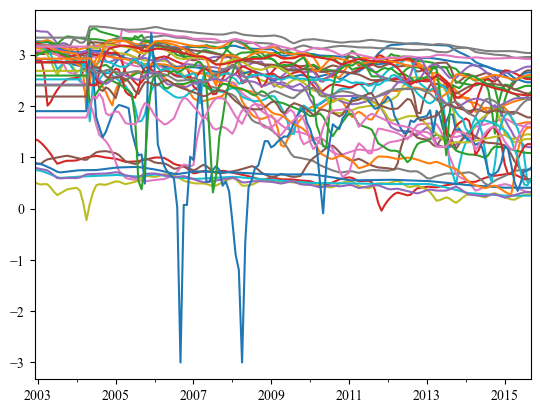

In [27]:
tr_interp.plot(legend=False)

In [28]:
# GETS APPROXIMATE tr VALUE IN THE XX GRID
def get_approx_predictions(X, y_map, XX):
    X_approx, y_approx = [],[]
    for i in range(X.shape[0]):
        x1, y1 = X.iloc[i].Easting, X.iloc[i].Northing # ACTUAL POINT
        abs_east = np.abs(XX.Easting-x1)
        abs_north= np.abs(XX.Northing-y1)
        c = np.maximum(abs_north,abs_east)
        index = np.argmin(c)
        XX.iloc[index].Easting, XX.iloc[index].Northing
        X_approx.append([XX.iloc[index].Easting, XX.iloc[index].Northing, XX.iloc[index].Elevation])
        y_approx.append(y_map[index])
    X_approx = pd.DataFrame(X_approx, columns=['Easting', 'Northing', 'Elevation'])
    return X_approx, y_approx

In [29]:
X = np.vstack((UTM_x,UTM_y, elev.values)).T
X = pd.DataFrame(X, columns=['Easting', 'Northing', 'Elevation'])

XX = np.vstack([x_loc.flatten(), y_loc.flatten(), farea_dem.flatten(), slope.flatten(), accum.flatten()]).T
XX = pd.DataFrame(XX, columns=['Easting', 'Northing', 'Elevation', 'Slope', 'Acc'])

X_approx, Slope_X = get_approx_predictions(X, slope.flatten(), XX)
X_approx, Acc_X = get_approx_predictions(X, accum.flatten(), XX)

X = np.vstack((UTM_x,UTM_y, elev.values, Slope_X, Acc_X)).T
X = pd.DataFrame(X, columns=['Easting', 'Northing', 'Elevation', 'Slope', 'Acc'])

In [30]:
year = 2015
y = np.array(tr_interp.loc[tr_interp.index[pd.Series(tr_interp.index).dt.year == year]].mean())
print(y)
station_names = list(tr_interp.columns)

[2.53937381 1.73585499 2.452686   0.62319239 1.39183798 2.50963205
 1.65149981 0.72328054 1.41132869 1.34673475 2.57738302 2.09502347
 2.37203081 2.60490224 2.70073832 0.8612056  0.39576523 2.95425281
 0.22368195 0.25053464 0.40502561 0.95790845 1.12593219 0.96896256
 0.27558381 2.30711508 2.92656853 3.05159618 1.35084861 0.96369776
 0.76489731 2.55573003 2.22637235 2.23695105 2.13047544 1.8404908
 1.39984221 1.96552464]


In [31]:
def dist(p1,p2):
    return sqrt(((p1[0]-p2[0])**2)+((p1[1]-p2[1])**2))

def add_dist_to_basin(XX, basin_coordinate=[436642.70,3681927.09], col_name='dist_to_basin'):
    x1,y1 = basin_coordinate
    distances = []
    for i in range(XX.shape[0]):
        x2,y2 = XX.iloc[i][0], XX.iloc[i][1]
        distances.append(dist([x1,y1],[x2,y2]))
    XX[col_name] = distances
    return XX

In [32]:
b_c=[436642.70,3681927.09]
XX = add_dist_to_basin(XX, basin_coordinate=b_c)
X = add_dist_to_basin(X, basin_coordinate=b_c)

In [34]:
y_map, r_map, residuals, lr_trend, model = pylenm_df.interpolate_topo(X, y, XX, ft=['Elevation', 'dist_to_basin'], regression='linear', smooth=True)
y_map[y_map<0] = 0

<Axes: >

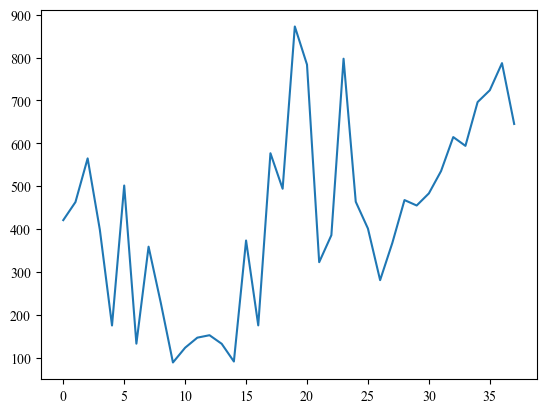

In [35]:
X.dist_to_basin.plot()

## Build the spatial model

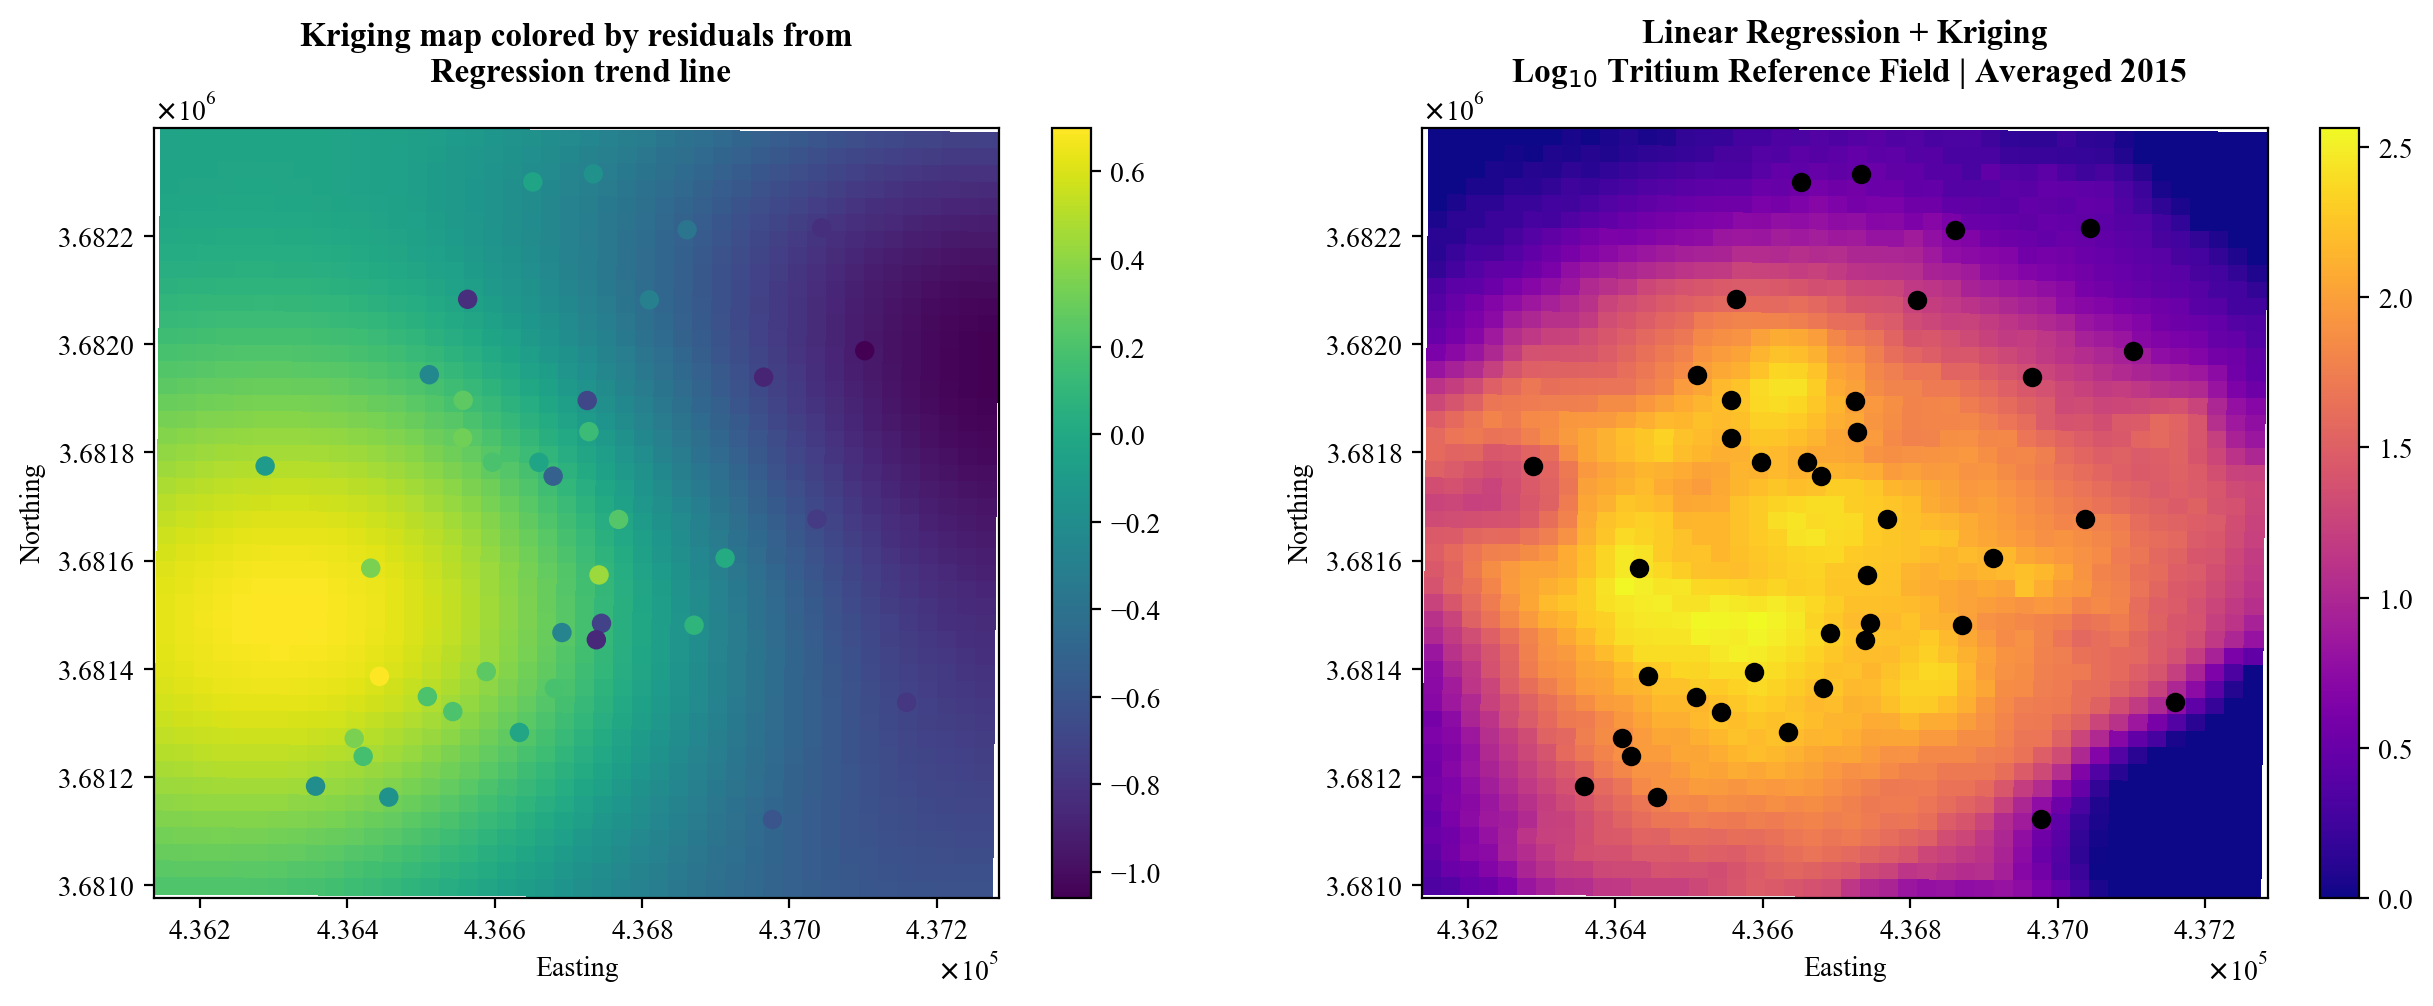

In [36]:
# Plot all result details
fig, ax = plt.subplots(1,2, figsize=(15,5), dpi=200)
xx = np.array(XX)
titles = ["Kriging map colored by residuals from\n Regression trend line", str("Linear Regression + Kriging\n Log{} Tritium Reference Field | {}{}".format('$_{10}$',"Averaged ",year,))]
map_0 = ax[0].pcolor(xx[:,0].reshape(x_loc.shape),
                xx[:,1].reshape(x_loc.shape),
                r_map.reshape(x_loc.shape))
fig.colorbar(map_0, ax=ax[0])
map_1 = ax[1].pcolor(xx[:,0].reshape(x_loc.shape),
                xx[:,1].reshape(x_loc.shape),
                y_map.reshape(x_loc.shape), 
                cmap='plasma')
fig.colorbar(map_1, ax=ax[1])
colors=[residuals, 'black']
# ax[0].scatter(X.iloc[:,0], X.iloc[:,1], c=colors, alpha=1)
for i in range(2):
    ax[i].scatter(X.iloc[:,0], X.iloc[:,1], c=colors[i], alpha=1)
    ax[i].set_xlabel("Easting")
    ax[i].set_ylabel("Northing")
    ax[i].set_title(titles[i],y=1.04,fontweight='bold')
    ax[i].ticklabel_format(style='sci', axis='both',scilimits=(-1,1), useMathText=True)
fig.show()

In [38]:
pd.set_option('max_colwidth', 100)

# TEST ALL - Regular Fitting Process
model_results = pd.DataFrame(columns=['model', 'features', 'mse', 'r2'])

# Save GP results 
gp, y_map_gp = pylenm_df.fit_gp(X=X[['Easting', 'Northing']], y=y, xx=XX[['Easting', 'Northing']])
# y_map_gp = y_map_gp_here
X_approx, y_approx = get_approx_predictions(X, y_map_gp, XX)
model_results.loc[len(model_results.index)] = ["GP", np.nan, pylenm_df.mse(y, y_approx), r2_score(y, y_approx)]

feature_params = [['Elevation'], ['Elevation', 'dist_to_basin'],['Elevation', 'Slope'], ['Elevation', 'Slope', 'dist_to_basin'], ['Easting', 'Northing'], ['Easting', 'Northing', 'Elevation'], ['Easting', 'Northing', 'Elevation', 'dist_to_basin'],
['Easting', 'Northing', 'Elevation', 'Slope'], ['Easting', 'Northing', 'Elevation', 'Slope', 'dist_to_basin'], ['Easting', 'Northing', 'Elevation', 'Slope', 'Acc'], ['Easting', 'Northing', 'Elevation', 'Slope', 'Acc', 'dist_to_basin']]

# Save Results for our approach  
for ft in feature_params:
    y_map_lr, r_map_lr, residuals_lr, lr_trend, model = pylenm_df.interpolate_topo(X, y, XX, ft=ft, regression='linear', smooth=True)
    y_map_rf, r_map_rf, residuals_rf, rf_trend, model = pylenm_df.interpolate_topo(X, y, XX, ft=ft, regression='rf', smooth=True)
    y_map_rid, r_map_rid, residual_rid, rid_trend, model = pylenm_df.interpolate_topo(X, y, XX, ft=ft, regression='ridge', smooth=True)
    y_map_las, r_map_las, residuals_las, las_trend, model = pylenm_df.interpolate_topo(X, y, XX, ft=ft, regression='lasso', smooth=True)
    y_map_lr[y_map_lr<0] = 0
    y_map_rf[y_map_rf<0] = 0
    y_map_rid[y_map_rid<0] = 0
    y_map_las[y_map_las<0] = 0

    y_maps = [y_map_lr, y_map_rf, y_map_rid, y_map_las]
    model_names = ["Linear", "Random Forest", "Ridge", "Lasso"]
    for y_map, model_name in zip(y_maps, model_names):
        X_approx, y_approx = get_approx_predictions(X, y_map, XX)
        model_results.loc[len(model_results.index)] = [model_name, ft, pylenm_df.mse(y, y_approx), r2_score(y, y_approx)]

In [39]:
model_results.sort_values(by='r2', ascending=False)

,model,features,mse,r2
40,Lasso,"[Easting, Northing, Elevation, Slope, Acc]",0.003014,0.995873
32,Lasso,"[Easting, Northing, Elevation, Slope]",0.003014,0.995873
31,Ridge,"[Easting, Northing, Elevation, Slope]",0.004766,0.993473
12,Lasso,"[Elevation, Slope]",0.004880,0.993317
29,Linear,"[Easting, Northing, Elevation, Slope]",0.005624,0.992298
39,Ridge,"[Easting, Northing, Elevation, Slope, Acc]",0.005694,0.992201
37,Linear,"[Easting, Northing, Elevation, Slope, Acc]",0.007462,0.989780
44,Lasso,"[Easting, Northing, Elevation, Slope, Acc, dist_to_basin]",0.018918,0.974092
42,Random Forest,"[Easting, Northing, Elevation, Slope, Acc, dist_to_basin]",0.021418,0.970668
30,Random Forest,"[Easting, Northing, Elevation, Slope]",0.023685,0.967562


### Model assessment - leave-one-out cross validation

In [41]:
# TEST ALL - Leave-One-Out Cross Validation Process
model_results_LOO = pd.DataFrame(columns=['model', 'features', 'mse', 'r2'])

# Save GP results
y_approx_loo_gp = []
loo = LeaveOneOut()
for train_index, test_index in loo.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y[train_index], y[test_index]
    gp, y_map_gp = pylenm_df.fit_gp(X=X_train[['Easting', 'Northing']], y=y_train, xx=XX[['Easting', 'Northing']])
    X_approx_test_gp, y_approx_test_gp = get_approx_predictions(X_test, y_map_gp, XX)
    y_approx_loo_gp.append(y_approx_test_gp)
model_results_LOO.loc[len(model_results_LOO.index)] = ["GP", np.nan, pylenm_df.mse(y, y_approx_loo_gp), r2_score(y, y_approx_loo_gp)]

feature_params = [['Elevation'], ['Elevation', 'dist_to_basin'],['Elevation', 'Slope'], ['Elevation', 'Slope', 'dist_to_basin'], ['Easting', 'Northing'], ['Easting', 'Northing', 'Elevation'], ['Easting', 'Northing', 'Elevation', 'dist_to_basin'],
['Easting', 'Northing', 'Elevation', 'Slope'], ['Easting', 'Northing', 'Elevation', 'Slope', 'dist_to_basin'], ['Easting', 'Northing', 'Elevation', 'Slope', 'Acc'], ['Easting', 'Northing', 'Elevation', 'Slope', 'Acc', 'dist_to_basin']]

# Save Results for our approach  
for ft in feature_params:
    y_approx_loo_lr, y_approx_loo_rf, y_approx_loo_rid, y_approx_loo_las = [], [], [], []
    loo = LeaveOneOut()
    for train_index, test_index in loo.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y[train_index], y[test_index]
        
        y_map_lr, r_map_lr, residuals_lr, lr_trend, model = pylenm_df.interpolate_topo(X_train, y_train, XX, ft=ft, regression='linear', smooth=True)
        y_map_rf, r_map_rf, residuals_rf, rf_trend, model = pylenm_df.interpolate_topo(X_train, y_train, XX, ft=ft, regression='rf', smooth=True)
        y_map_rid, r_map_rid, residual_rid, rid_trend, model = pylenm_df.interpolate_topo(X_train, y_train, XX, ft=ft, regression='ridge', smooth=True)
        y_map_las, r_map_las, residuals_las, las_trend, model = pylenm_df.interpolate_topo(X_train, y_train, XX, ft=ft, regression='lasso', smooth=True)
        
        y_map_lr[y_map_lr<0] = 0
        y_map_rf[y_map_rf<0] = 0
        y_map_rid[y_map_rid<0] = 0
        y_map_las[y_map_las<0] = 0

        X_approx_test_lr, y_approx_test_lr = get_approx_predictions(X_test, y_map_lr, XX)
        X_approx_test_rf, y_approx_test_rf = get_approx_predictions(X_test, y_map_rf, XX)
        X_approx_test_rid, y_approx_test_rid = get_approx_predictions(X_test, y_map_rid, XX)
        X_approx_test_las, y_approx_test_las = get_approx_predictions(X_test, y_map_las, XX)
        
        y_approx_loo_lr.append(y_approx_test_lr)
        y_approx_loo_rf.append(y_approx_test_rf)
        y_approx_loo_rid.append(y_approx_test_rid)
        y_approx_loo_las.append(y_approx_test_las)

    y_preds = [y_approx_loo_lr, y_approx_loo_rf, y_approx_loo_rid, y_approx_loo_las]
    model_names = ["Linear", "Random Forest", "Ridge", "Lasso"]
    for y_approx, model_name in zip(y_preds, model_names):
        model_results_LOO.loc[len(model_results_LOO.index)] = [model_name, ft, pylenm_df.mse(y, y_approx), r2_score(y, y_approx)]

In [43]:
model_results_LOO.sort_values(by='r2', ascending=False)

,model,features,mse,r2
25,Linear,"[Easting, Northing, Elevation, dist_to_basin]",0.404822,0.445583
27,Ridge,"[Easting, Northing, Elevation, dist_to_basin]",0.405623,0.444487
33,Linear,"[Easting, Northing, Elevation, Slope, dist_to_basin]",0.424165,0.419092
15,Ridge,"[Elevation, Slope, dist_to_basin]",0.424328,0.418869
13,Linear,"[Elevation, Slope, dist_to_basin]",0.426008,0.416568
16,Lasso,"[Elevation, Slope, dist_to_basin]",0.426009,0.416568
28,Lasso,"[Easting, Northing, Elevation, dist_to_basin]",0.434358,0.405133
35,Ridge,"[Easting, Northing, Elevation, Slope, dist_to_basin]",0.452136,0.380785
36,Lasso,"[Easting, Northing, Elevation, Slope, dist_to_basin]",0.456030,0.375452
41,Linear,"[Easting, Northing, Elevation, Slope, Acc, dist_to_basin]",0.460997,0.368650


In [45]:
y_map, r_map, residuals, trend, model = pylenm_df.interpolate_topo(X, y, XX, ft=['Easting', 'Northing', 'Elevation','Slope', 'Acc'], regression='lasso', smooth=True)
y_map[y_map<0] = 0

### Visualize results

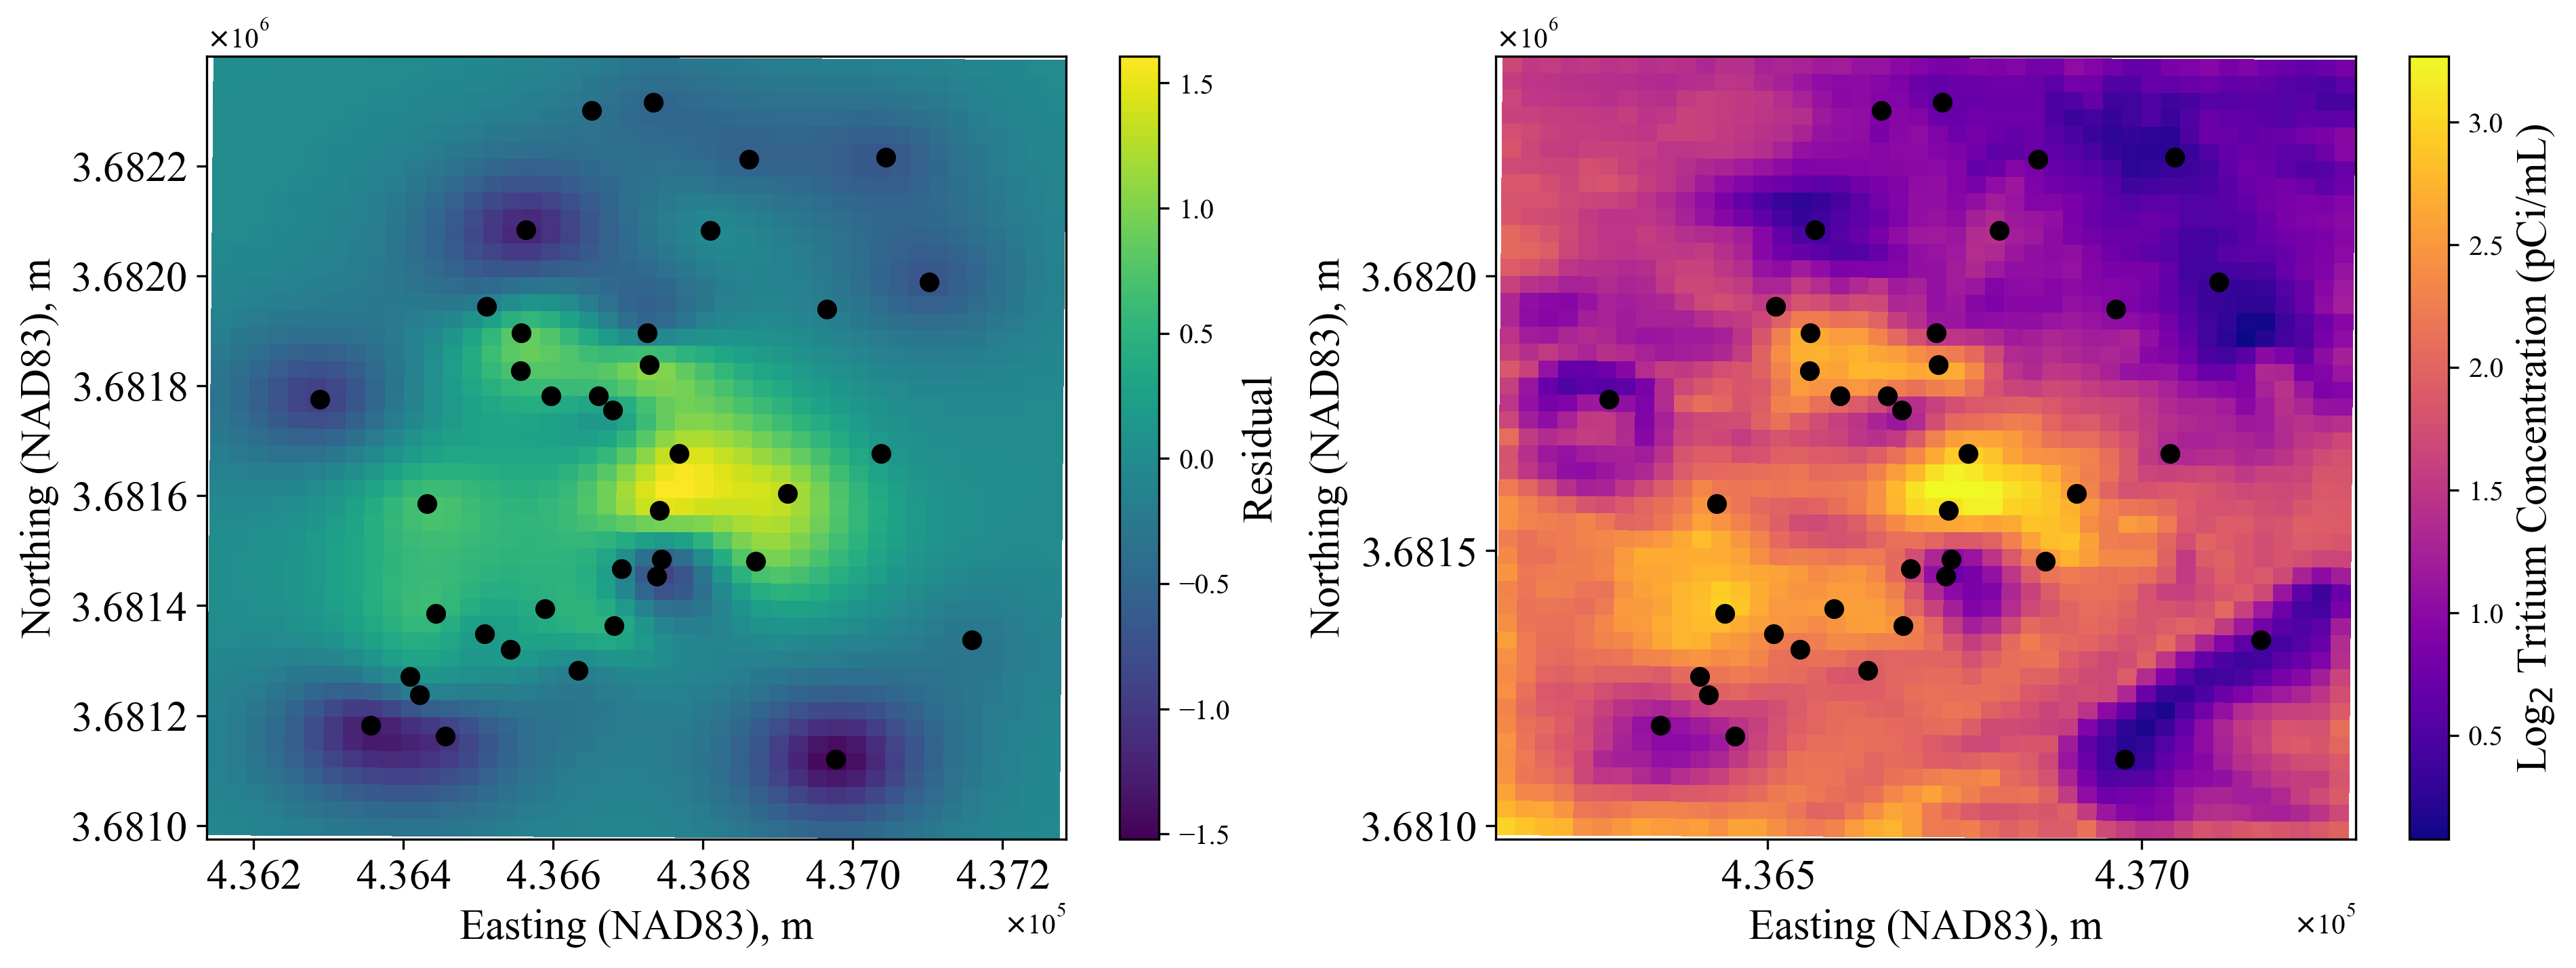

In [46]:
# Plot all result details
fig, ax = plt.subplots(1,2, figsize=(15,5), dpi=300)
fontsize=15
xx = np.array(XX)
plt.locator_params(axis='both', nbins=4, tight=False)
titles = ["Kriging map colored by residuals from\n Regression trend line", str("Linear Regression + Kriging\n Log{} Tritium Reference Field | {}".format('$_{2}$',"Averaged 2011",))]
map_0 = ax[0].pcolor(xx[:,0].reshape(x_loc.shape),
                xx[:,1].reshape(x_loc.shape),
                r_map.reshape(x_loc.shape))
fig.colorbar(map_0, ax=ax[0]).set_label(label='Residual',size=fontsize)
map_1 = ax[1].pcolor(xx[:,0].reshape(x_loc.shape),
                xx[:,1].reshape(x_loc.shape),
                y_map.reshape(x_loc.shape), 
                cmap='plasma')
fig.colorbar(map_1, ax=ax[1]).set_label(label="Log{} Tritium Concentration ({})".format('$_{2}$',pylenm_df.get_unit('TRITIUM')), size=fontsize)
colors=['black', 'black']
for i in range(2):
    ax[i].scatter(X.iloc[:,0], X.iloc[:,1], c=colors[i], alpha=1, cmap='plasma')
    plt.rc('font', size=fontsize)
    ax[i].tick_params(axis='both', which='major', labelsize=fontsize)
    ax[i].set_xlabel("Easting (NAD83), m", fontsize=fontsize)
    ax[i].set_ylabel("Northing (NAD83), m", fontsize=fontsize)
    ax[i].ticklabel_format(style='sci', axis='both',scilimits=(-1,1), useMathText=True)
plt.locator_params(axis='x', nbins=4, tight=False)
plt.locator_params(axis='y', nbins=4, tight=False)
fig.show()

In [47]:
X_approx, y_approx = get_approx_predictions(X, y_map, XX)

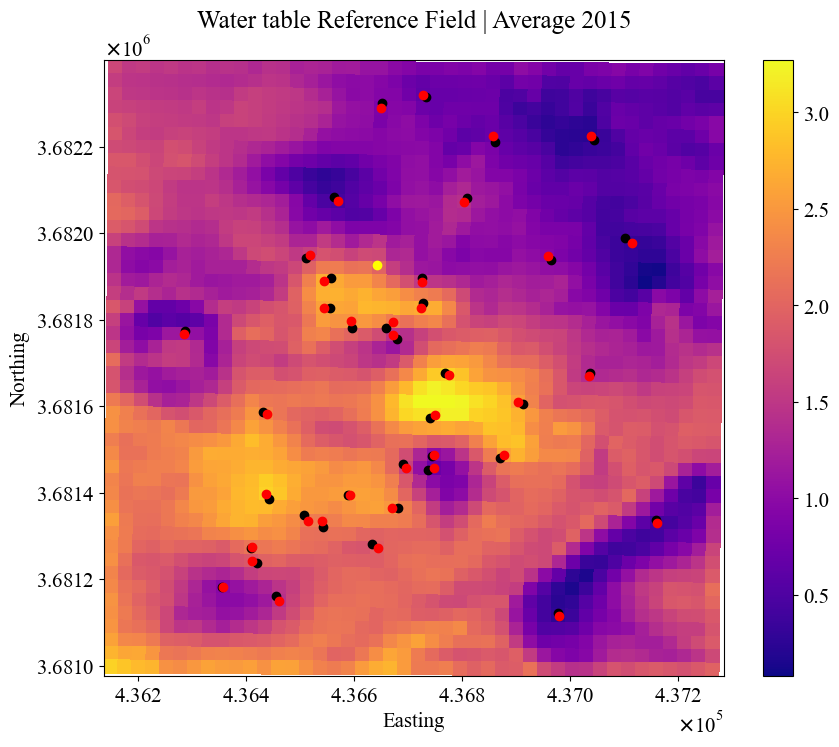

In [48]:
# Plot all result details
fig, ax = plt.subplots(1,1,figsize=(10,8))
xx = np.array(XX)
titles = [str("Water table Reference Field | Average {}".format(year))]
map_1 = ax.pcolor(xx[:,0].reshape(x_loc.shape),
                xx[:,1].reshape(x_loc.shape),
                y_map.reshape(x_loc.shape), 
                cmap='plasma')
fig.colorbar(map_1, ax=ax)
ax.scatter(X.iloc[:,0], X.iloc[:,1], c='black', alpha=1) # Real point
ax.scatter(X_approx.iloc[:,0], X_approx.iloc[:,1], c='red', alpha=1) # Approximate point
ax.scatter(b_c[0], b_c[1], c='yellow', alpha=1) # Approximate point
ax.set_xlabel("Easting")
ax.set_ylabel("Northing")
ax.set_title(titles[0],y=1.04)
ax.ticklabel_format(style='sci', axis='both',scilimits=(-1,1), useMathText=True)
fig.show()

MSE LR:  0.003013564500824703
R^2 LR:  0.9958728265238526
[0.    0.006 0.012 0.018 0.024 0.03 ]


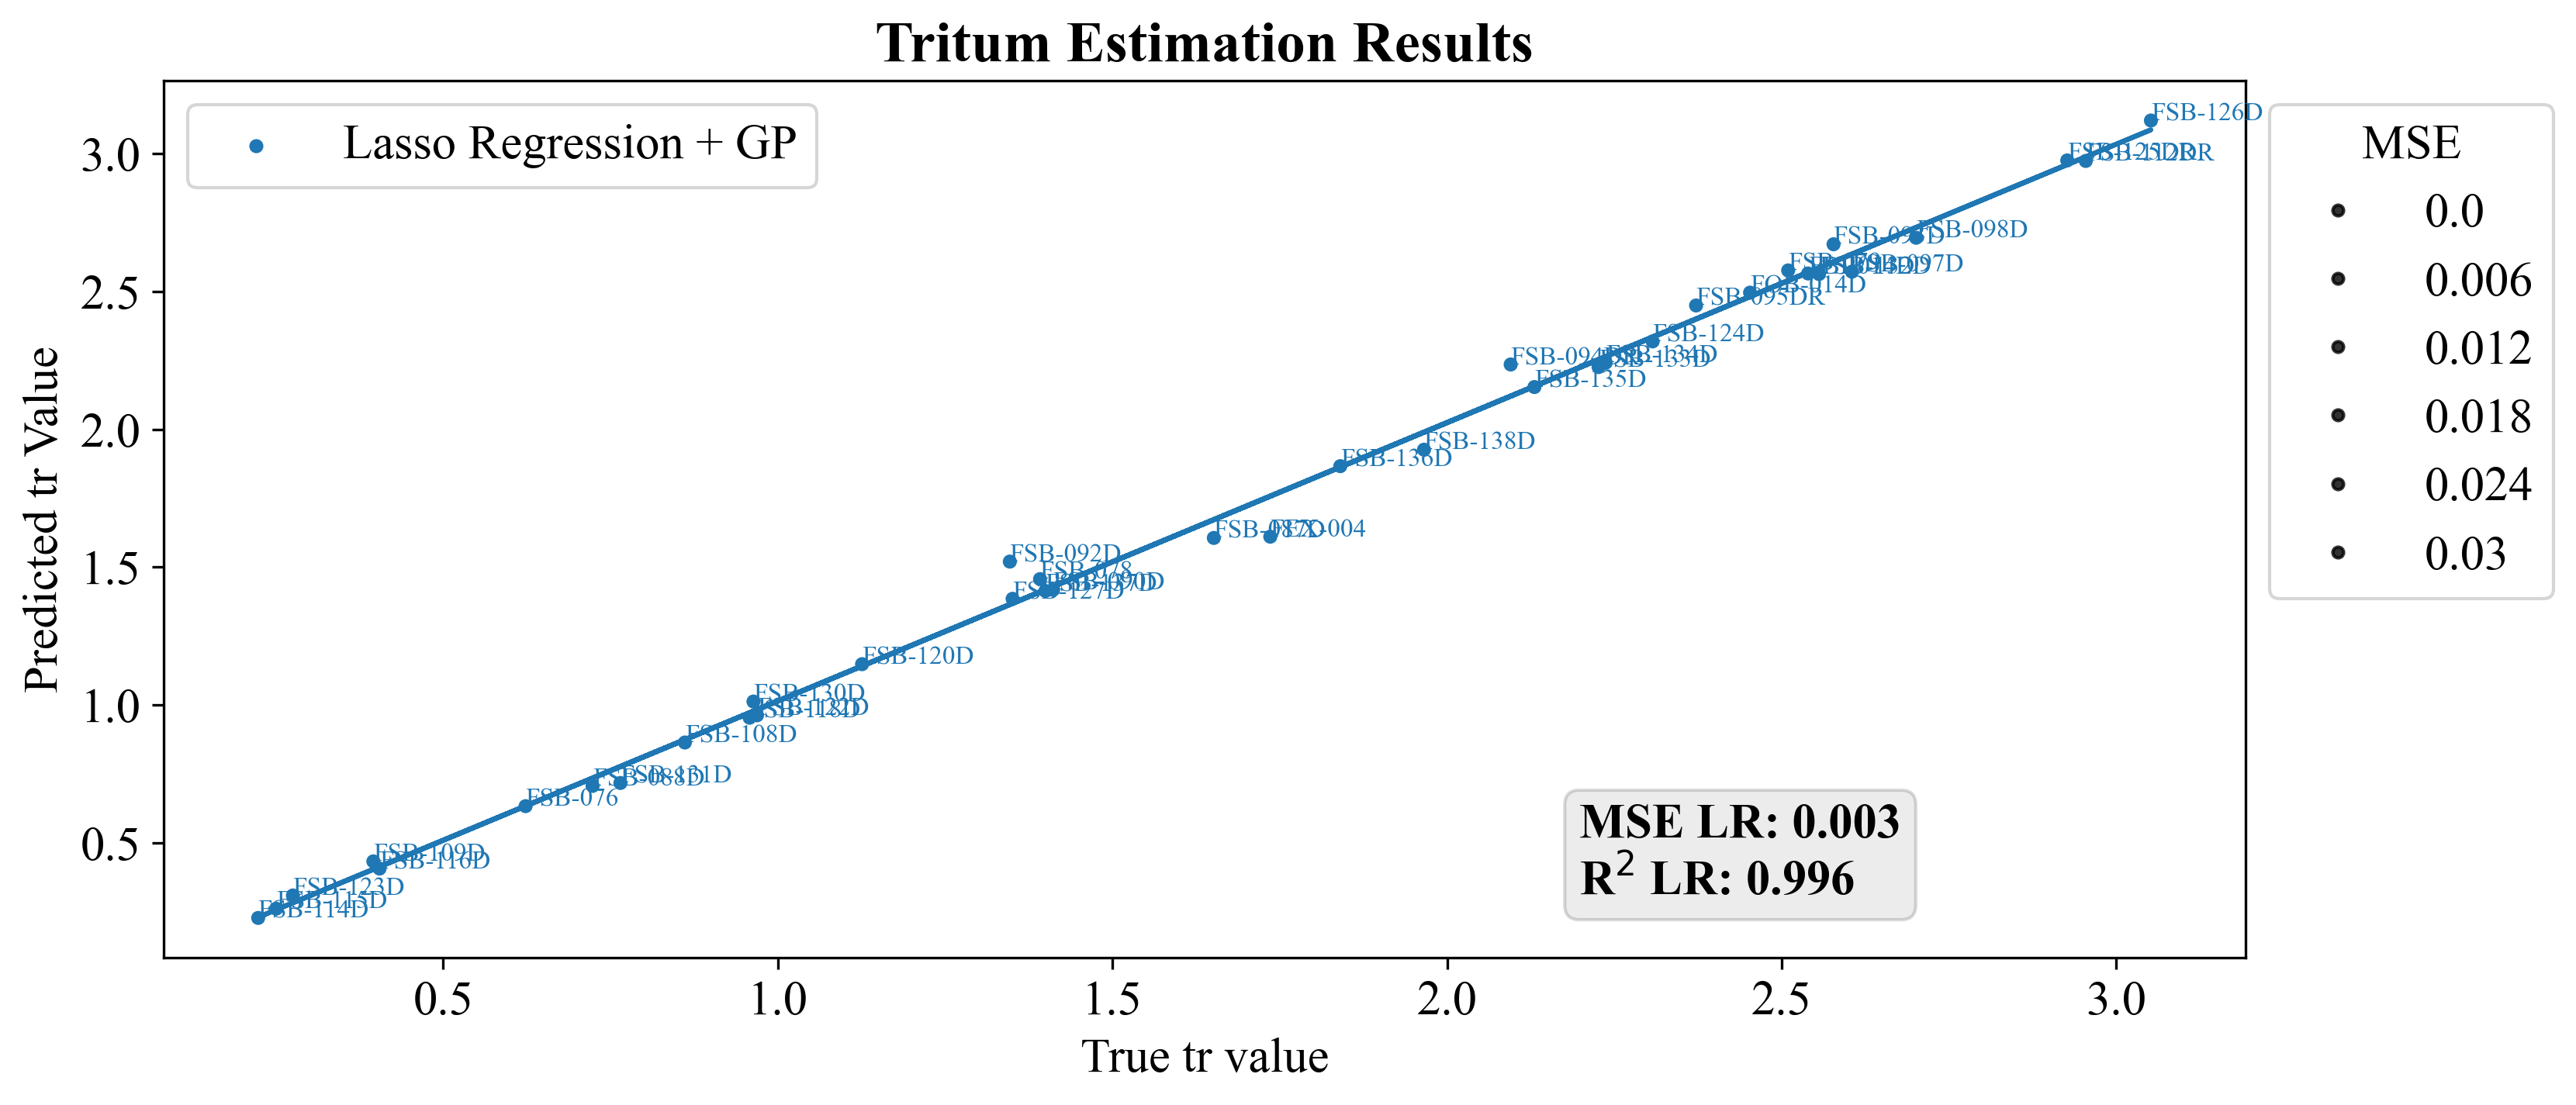

<Figure size 1280x960 with 0 Axes>

In [49]:
fig, ax = plt.subplots(figsize=(10,5),dpi=300)
plt.rcParams["legend.loc"] = 'upper left'
print("MSE LR: ",pylenm_df.mse(y, y_approx))

print("R^2 LR: ",r2_score(y, y_approx))
text = "MSE LR: {:.3f}".format(pylenm_df.mse(y, y_approx)) + "\n" + "R{} LR: {:.3f}".format('$^{2}$', r2_score(y, y_approx))
plt.figure( dpi=200)
ax.set_title('Tritum Estimation Results',fontweight='bold')
ax.set_xlabel('True tr value')
ax.set_ylabel('Predicted tr Value')

err_lr = []
for i in range(len(y)):
    err_lr.append(pylenm_df.mse([y[i]], [y_approx[i]]))
minmaxscaler=MinMaxScaler()
minmaxscaler.fit_transform(np.array(err_lr).reshape(-1,1)).flatten().tolist()

err_lr_s = [(x+5)**1.5 for x in err_lr]
scatter1 = ax.scatter(y, y_approx, label = "Lasso Regression + GP", s=err_lr_s)
props = dict(boxstyle='round', facecolor='grey', alpha=0.15)
fig.tight_layout()
fig.text(0.68, 0.06, text, transform=ax.transAxes, fontsize=15, fontweight='bold', verticalalignment='bottom', bbox=props) #1.025, 0.06

m_lr, b_lr = np.polyfit(y.astype("float64"), np.array(y_approx).flatten(), 1)

legend1 = ax.legend()
ax.add_artist(legend1)
# produce a legend with a cross section of sizes from the scatter
handles, labels = scatter1.legend_elements(prop="sizes", alpha=0.8)
labels=np.round(np.linspace(min(np.array(err_lr).min(),np.array(err_lr).min()), max(np.array(err_lr).max(),np.array(err_lr).max()) ,6),3)
print(labels)
legend2 = ax.legend(handles, labels, title="MSE", bbox_to_anchor=(1, 1), loc='upper left', ncol=1)
for i, txt in enumerate(station_names):
    ax.annotate(txt, (y[i], y_approx[i]), fontsize=8, color='#1f77b4')

ax.plot(y, m_lr*y + b_lr)